# Shared-context caching across a multi-agent pipeline — and where it stops paying

Multi-agent pipelines reuse the same large context everywhere. A planner, a
worker, and a reviewer all need the same task spec, the same reference data, the
same house rules. Without caching, every step pays full input price for that
shared block again. [Prompt caching](https://platform.claude.com/docs/en/build-with-claude/prompt-caching)
fixes that: cache the shared prefix once, and later steps read it at a fraction
of the price.

This notebook is about the part that is less obvious. In a real pipeline the
"shared" context is not static. The planner tightens a constraint, the worker
emits a partial result, and that output becomes input the next step needs.
Prompt caching is a **prefix match** — any byte change to the cached prefix
invalidates it, and the next call pays to write the cache again. So there is a
crossover: below some prefix mutation frequency, caching saves you most of the
cost; above it, you are re-writing the cache so often that you would have been
better off not caching at all.

We will:

1. Run a 3-step pipeline that shares one context block, with and without caching,
   and read the real cost off `usage`.
2. Build the cost as a transparent model of the published cache multipliers.
3. **Measure the crossover** — sweep the prefix mutation rate and find where
   caching stops paying.
4. Apply the one structural fix that recovers caching, and name the question it
   does *not* answer: once the shared state both evolves and has to be current,
   you have left a cost problem and entered a coherence one.

This is the multi-agent, mutating-prefix companion to
[`misc/prompt_caching.ipynb`](prompt_caching.ipynb), which covers the single
large-document case. It grew out of the discussion on
[cookbook issue #596](https://github.com/anthropics/claude-cookbooks/issues/596).

All calls use `claude-haiku-4-5` to keep spend minimal, and the cost model runs
with no API key at all.

## Setup

In [ ]:
%pip install --upgrade "anthropic>=0.83.0" matplotlib --quiet

In [ ]:
import os

import anthropic

# Resolves ANTHROPIC_API_KEY from the environment. The live demo below is
# guarded on the key being present; every other section runs without one.
client = anthropic.Anthropic()
MODEL = "claude-haiku-4-5"  # current low-cost model (see CONTRIBUTING.md)

## 1. The shared context and the pipeline

Our pipeline is the canonical shape: **planner → worker → reviewer**, each a
single call, all three sharing one context block (a task brief plus reference
material). We put that shared block in the `system` prompt and cache it with
`cache_control`.

One thing that bites people first: on `claude-haiku-4-5` the **minimum
cacheable prefix is 4096 tokens**. A shorter prefix silently will not cache —
no error, just `cache_creation_input_tokens: 0`. So we make the shared context
comfortably larger than that, and we will verify the cache actually engaged by
reading `usage`.

In [1]:
def build_shared_context(n_modules: int = 80) -> str:
    """A realistic, deterministic shared context: a project brief plus a
    per-module reference table. Sized to clear the 4096-token cache minimum."""
    header = (
        "PROJECT BRIEF — Orders service refactor\n"
        "All agents share these rules. Follow them exactly; do not restate them.\n"
        "Style: snake_case functions, type hints, no comments that restate code.\n"
        "Errors: raise typed exceptions, never swallow. Money is integer cents.\n\n"
        "MODULE REFERENCE\n"
    )
    rows = []
    for i in range(n_modules):
        rows.append(
            f"- module orders.svc{i:02d}: owns table `orders_{i:02d}`; "
            f"exposes get_order(id)->Order, place_order(cart)->OrderId, "
            f"cancel_order(id)->None. Invariants: total == sum(line_totals); "
            f"status in {{open, paid, shipped, cancelled}}; a cancelled order "
            f"never transitions again. Rate limit 50 rps. Owner team: fulfilment."
        )
    return header + "\n".join(rows) + "\n"


SHARED_CONTEXT = build_shared_context()
approx_tokens = len(SHARED_CONTEXT) // 4  # ~4 chars/token, rough
print(f"shared context: {len(SHARED_CONTEXT)} chars (~{approx_tokens} tokens, estimated)")
print("estimated to clear Haiku's 4096-token cache minimum:", approx_tokens > 4096)
print("(the authoritative check is cache_creation_input_tokens > 0 on the live call)")

shared context: 24113 chars (~6028 tokens, estimated)
estimated to clear Haiku's 4096-token cache minimum: True
(the authoritative check is cache_creation_input_tokens > 0 on the live call)


Each step sends the shared context as a cached `system` block and its own small,
per-step instruction as the user turn. The instruction and the prior step's
output go *after* the cached prefix, so they do not invalidate it.

In [ ]:
def run_step(instruction: str, prior_state: str, use_cache: bool):
    """One pipeline step. The shared context is the (optionally cached) system
    prefix; the step-specific instruction and prior output are the user turn."""
    system_block = {"type": "text", "text": SHARED_CONTEXT}
    if use_cache:
        system_block["cache_control"] = {"type": "ephemeral"}  # 5-min TTL
    return client.messages.create(
        model=MODEL,
        max_tokens=400,
        system=[system_block],
        messages=[
            {
                "role": "user",
                "content": f"{instruction}\n\nPrior step output:\n{prior_state}",
            }
        ],
    )


def usage_row(label, u):
    print(
        f"{label:<24} write={u.cache_creation_input_tokens:>6} "
        f"read={u.cache_read_input_tokens:>6} uncached={u.input_tokens:>5}"
    )


STEPS = [
    ("PLANNER: list the files to change for adding a discount field.", "(none)"),
    ("WORKER: write the change for the first file in the plan.", ""),
    ("REVIEWER: check the change against the shared invariants.", ""),
]

if not os.environ.get("ANTHROPIC_API_KEY"):
    print("No ANTHROPIC_API_KEY set — skipping the billed live calls.")
    print("The cost-model sections below need no key and no spend.")
else:
    for use_cache in (False, True):
        print(f"\n=== caching {'ON' if use_cache else 'OFF'} ===")
        prior = ""
        for instruction, seed in STEPS:
            msg = run_step(instruction, prior or seed, use_cache)
            usage_row(instruction.split(":")[0], msg.usage)
            prior = next((b.text for b in msg.content if b.type == "text"), "")

**What you see when you run it with a key.** With caching **off**, every step
reports the full shared context under `uncached` and `write`/`read` stay at `0`.
With caching **on**, the planner shows a non-zero `cache_creation` (it wrote the
prefix), and the worker and reviewer show a non-zero `cache_read` with the
shared prefix gone from `uncached` — they read it at 0.1x instead of paying full
price. If `cache_read` is `0` on the later steps, your prefix was under the
4096-token minimum.

That is the happy path: a static shared prefix. The rest of the notebook is
about what happens when the prefix is *not* static — which, in a real pipeline,
it usually is not.

## 2. The token economics, as a transparent model

Caching cost is just token accounting against three published multipliers on the
base input price. We can compute it directly from `usage`, with no key and no
guessing. ([pricing reference](https://platform.claude.com/docs/en/build-with-claude/prompt-caching))

In [2]:
# Multipliers on the base input-token price.
CACHE_WRITE_5M = 1.25  # writing a 5-minute-TTL cache entry
CACHE_WRITE_1H = 2.00  # writing a 1-hour-TTL cache entry
CACHE_READ = 0.10  # reading any cache entry
UNCACHED = 1.00  # processing a token normally

HAIKU_INPUT_PER_TOKEN = 1.00 / 1_000_000  # $1.00 / 1M input tokens


def request_input_cost(usage: dict, base_per_token: float = HAIKU_INPUT_PER_TOKEN) -> float:
    """Dollar input cost of one request, straight from its usage fields."""
    return base_per_token * (
        usage["input_tokens"] * UNCACHED
        + usage["cache_creation_input_tokens"] * CACHE_WRITE_5M
        + usage["cache_read_input_tokens"] * CACHE_READ
    )


# A 6000-token shared prefix, read once vs. written once:
read = {"input_tokens": 0, "cache_creation_input_tokens": 0, "cache_read_input_tokens": 6000}
write = {"input_tokens": 0, "cache_creation_input_tokens": 6000, "cache_read_input_tokens": 0}
print(f"reading 6k cached tokens:  ${request_input_cost(read):.6f}")
print(f"writing 6k cached tokens:  ${request_input_cost(write):.6f}")
print(f"a cache write costs {CACHE_WRITE_5M / UNCACHED:.2f}x an uncached read of the same tokens")

reading 6k cached tokens:  $0.000600
writing 6k cached tokens:  $0.007500
a cache write costs 1.25x an uncached read of the same tokens


That last line is the whole game. A cache **write** costs 1.25x what it would
cost to just send those tokens uncached. So caching is a bet: you pay 1.25x once,
betting that enough later reads at 0.1x will more than pay it back. If the prefix
changes before you can read it, you pay 1.25x **again** — and re-writing the
cache on every step is *more expensive than never caching at all*.

## 3. The crossover — sweep the prefix mutation rate

Model the shared prefix across an `n`-step pipeline. Step 1 always writes the
cache. Each later step either **re-writes** it (the prefix changed since it was
cached — a cache miss, probability `mutation_rate`) or **reads** it
(probability `1 - mutation_rate`).

In [3]:
def prefix_input_multiplier(n_steps, mutation_rate, cache_write=CACHE_WRITE_5M):
    """Expected total input multiplier for the shared prefix across the pipeline,
    in units of the base input price."""
    per_later = mutation_rate * cache_write + (1 - mutation_rate) * CACHE_READ
    return cache_write + (n_steps - 1) * per_later


def no_cache_prefix_multiplier(n_steps):
    """Without caching, every step pays full price for the shared prefix."""
    return n_steps * UNCACHED


def prefix_savings(n_steps, mutation_rate, cache_write=CACHE_WRITE_5M):
    """Fraction of shared-prefix input cost that caching saves vs. no caching.
    Negative means caching costs MORE than just paying uncached."""
    cached = prefix_input_multiplier(n_steps, mutation_rate, cache_write)
    return 1 - cached / no_cache_prefix_multiplier(n_steps)


def crossover_rate(n_steps, cache_write=CACHE_WRITE_5M):
    """Mutation rate at which caching's savings reach zero (closed form)."""
    n = n_steps
    return (n - cache_write - (n - 1) * CACHE_READ) / ((n - 1) * (cache_write - CACHE_READ))


for n in (3, 5, 10):
    print(
        f"n={n:>2}: static-prefix savings={prefix_savings(n, 0.0):5.1%}  "
        f"crossover at mutation_rate={crossover_rate(n):.2f}"
    )

n= 3: static-prefix savings=51.7%  crossover at mutation_rate=0.67
n= 5: static-prefix savings=67.0%  crossover at mutation_rate=0.73
n=10: static-prefix savings=78.5%  crossover at mutation_rate=0.76


A static prefix (`mutation_rate = 0`) saves more as the pipeline grows — the
52% / 67% / 79% just printed for 3 / 5 / 10 steps, approaching a 90% ceiling (the
0.1x read multiplier) only for very long pipelines. As the prefix churns, the
savings decay and eventually go negative. Let's draw the whole curve, for both
the 5-minute and the 1-hour cache (the 1-hour write costs 2x, so it crosses
sooner).

3-step pipeline (5-min cache) crosses zero at mutation_rate = 0.67
3-step pipeline (1-hour cache) crosses zero at mutation_rate = 0.21


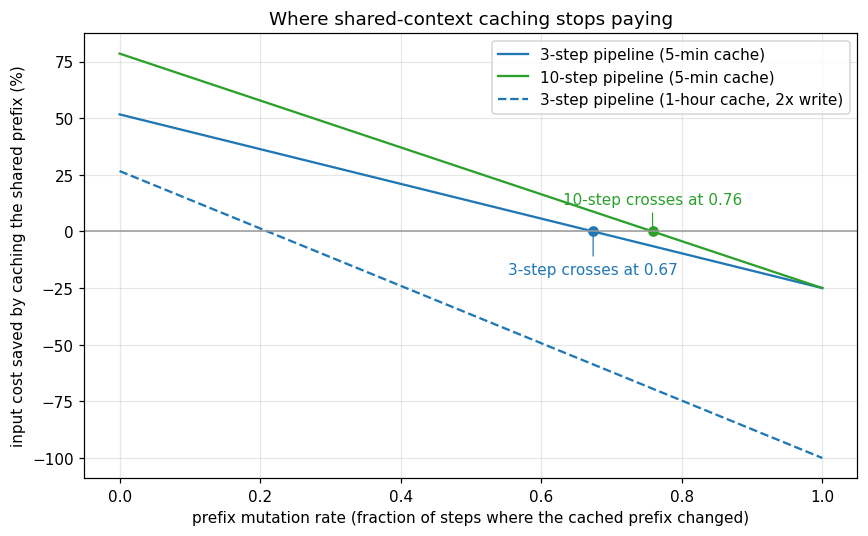

In [4]:
import matplotlib.pyplot as plt
import numpy as np

rates = np.linspace(0, 1, 101)
fig, ax = plt.subplots(figsize=(8, 5))

for n, color, dy in [(3, "#1f77b4", -28), (10, "#2ca02c", 18)]:
    ax.plot(
        rates,
        [prefix_savings(n, r) * 100 for r in rates],
        color=color,
        label=f"{n}-step pipeline (5-min cache)",
    )
    xc = crossover_rate(n)
    ax.plot(xc, 0, "o", color=color)
    ax.annotate(
        f"{n}-step crosses at {xc:.2f}",
        (xc, 0),
        xytext=(0, dy),
        textcoords="offset points",
        color=color,
        ha="center",
        arrowprops=dict(arrowstyle="-", color=color, lw=0.8),
    )

ax.plot(
    rates,
    [prefix_savings(3, r, CACHE_WRITE_1H) * 100 for r in rates],
    color="#1f77b4",
    ls="--",
    label="3-step pipeline (1-hour cache, 2x write)",
)

ax.axhline(0, color="#999", lw=1)
ax.set_xlabel("prefix mutation rate (fraction of steps where the cached prefix changed)")
ax.set_ylabel("input cost saved by caching the shared prefix (%)")
ax.set_title("Where shared-context caching stops paying")
ax.legend(loc="upper right")
ax.grid(alpha=0.3)
fig.tight_layout()
plt.show()

print(f"3-step pipeline (5-min cache) crosses zero at mutation_rate = {crossover_rate(3):.2f}")
print(
    f"3-step pipeline (1-hour cache) crosses zero at mutation_rate = {crossover_rate(3, CACHE_WRITE_1H):.2f}"
)

So, to answer the question directly — *at what prefix mutation frequency does
caching stop being cost-effective?* For a 3-step pipeline on the 5-minute cache,
at about **0.67**: once the shared prefix changes on more than ~two-thirds of the
steps, you are re-writing the cache often enough that paying uncached would have
been cheaper. The 1-hour cache, with its 2x write premium, crosses far earlier,
around **0.21**. Longer pipelines tolerate more churn (the crossover drifts up
into the high 0.70s) because the one unavoidable first write is amortized over
more steps.

Three honest caveats, because the engineers reading this will check:

- **These percentages are of the *shared-prefix input cost* only.** Per-step
  unique input and all output tokens are identical with and without caching, so
  they cancel out of the savings — and out of the crossover *rate*, which is why
  the crossover is robust. But they are real cost these percentages exclude (on
  Haiku, output is 5x the input price), so size a budget on absolute token counts,
  not on a headline percentage of one slice of the request.
- **This is arithmetic, not a benchmark.** Given the mutation rate it is just
  counting writes and reads at their published prices. The value is the *shape* —
  it tells you which regime your workload is in. The number you actually need is
  your own prefix mutation rate; read your crossover off the x-axis.
- **Caching is byte-level, not semantic.** It re-writes whenever the prefix
  *changed*, with no idea whether the change was relevant. A reordered key or a
  refreshed timestamp in the prefix costs you a full re-write for nothing. The
  model above charges every re-write at the original prefix size, so if you grow
  the prefix by appending state it is the optimistic floor — but it charges every
  mutation as a real write, because that is what the API does.

## 4. The fix that recovers caching — and the one it doesn't

The structural mistake that drives `mutation_rate` toward 1 is **growing the
cached prefix with each step's output**: append the planner's result to the
shared block, and now the worker's prefix differs, so it re-writes; append the
worker's result, and the reviewer re-writes again. You have turned a cacheable
constant into something that changes every step.

The fix is the standard prompt-caching discipline: **stable content before the
breakpoint, volatile content after it.** Keep the genuinely-static shared context
(task brief, reference data) as the cached prefix, and pass each step's evolving
output *after* the cache breakpoint, where changing it invalidates nothing.

In [5]:
N = 3
# (a) evolving state folded INTO the cached prefix -> it changes every step
savings_folded = prefix_savings(N, mutation_rate=1.0)
# (b) evolving state kept AFTER the breakpoint -> the static prefix never changes
savings_split = prefix_savings(N, mutation_rate=0.0)

print(
    f"evolving state inside the cached prefix:  {savings_folded:6.1%} saved (you are paying to re-cache)"
)
print(f"static prefix cached, state after it:     {savings_split:6.1%} saved")
print()
print("Same pipeline, same tokens. The only change is where the breakpoint sits")
print("relative to the part that mutates.")

evolving state inside the cached prefix:  -25.0% saved (you are paying to re-cache)
static prefix cached, state after it:      51.7% saved

Same pipeline, same tokens. The only change is where the breakpoint sits
relative to the part that mutates.


## 5. Beyond caching: shared *and* current

Splitting static from volatile recovers the **cost**. It does not answer the
question that shows up the moment intermediate state actually flows between
agents: **which version of that state did each agent act on?**

Caching is a cost optimization over a prefix. It has nothing to say about
correctness, because it was never trying to. Once the planner refines a
constraint *after* the worker already read the old one — a sequential stale read,
exactly the shape this pipeline has — you are no longer asking "how do I avoid
re-sending these tokens," you are asking "did this agent act on the current
version." (Run the steps concurrently and it is harder still: two writers can
race, and last-write-wins silently drops one.) Those are different problems, and
prompt caching only ever addressed the first.

When shared state evolves, the design space has three honest options, and they
compose rather than compete:

1. **Keep it in the prefix and pay the mutation cost.** The regime map above tells
   you when that is fine — low mutation rate, the cache still pays. Simplest; no
   new moving parts.
2. **Externalize the state to a store the agents read on demand** (a database, a
   memory or retrieval layer). This attacks the *broadcast* cost: instead of
   every agent carrying all intermediate state in its prefix, each pulls only
   what it needs. It answers "what should this agent retrieve," which is a
   relevance question.
3. **Version the shared state and coordinate reads against it.** This attacks the
   *currency* problem: a reader can tell whether the snapshot it is about to act
   on is still the latest, rather than silently acting on a stale one. It answers
   "is this agent acting on the current version," which is a coherence question.

These are orthogonal. Option 2 makes retrieval cheap and relevant but does not by
itself tell a reader its snapshot went stale under it — last-write-wins on a
shared store still loses a write if two agents race. Option 3 is what you reach
for when a stale read is not just wasteful but *wrong*. Most production pipelines
end up combining them: cache the static prefix, externalize the evolving state,
and version it if correctness depends on currency.

The useful exercise is to locate your own pipeline. Measure how often the shared
context behind your agents actually changes between steps, read the crossover off
the curve above, and decide which of these three you actually need. If the prefix
is calm, caching hands you most of your input cost back and you are done. If it
churns, caching is not your lever, and the question to ask next is whether the
churn is a cost problem or a correctness one.

## Key takeaways

- A multi-agent pipeline that shares a large context can cache that prefix once
  and read it back at 0.1x — saving around 52% of the shared-prefix input cost at
  3 steps and 79% at 10, approaching a 90% ceiling only for very long pipelines.
  (These percentages are of the cached prefix, not the whole request.)
- A cache **write** costs 1.25x an uncached send (2x for the 1-hour TTL). Caching
  is a bet that later reads pay back that premium.
- When the shared prefix mutates, that bet can lose: there is a **crossover**
  (around a 0.67 mutation rate for a 3-step, 5-minute-cache pipeline) past which
  re-writing the cache costs more than never caching. Measure your own mutation
  rate and read your crossover off the curve.
- The structural fix is breakpoint placement: **static content before the cache
  breakpoint, evolving state after it.**
- That fixes cost. Once the evolving shared state also has to be *current*, you
  have a coherence problem, not a caching one — a different layer of the stack.

### References
- [Prompt caching](https://platform.claude.com/docs/en/build-with-claude/prompt-caching)
- [`misc/prompt_caching.ipynb`](prompt_caching.ipynb) — the single large-document case
- [`misc/speculative_prompt_caching.ipynb`](speculative_prompt_caching.ipynb) — warming the cache ahead of the user